In [72]:
import pandas as pd

from marginal_emissions.core.msdr import MSDRAnalyzer
from marginal_emissions.utils.helper import plot_over_time, diagnose_model_fit

## Test Run with shorter Dataset

In [10]:
test = pd.read_csv('../data/processed/test_tennet.csv', index_col=0, decimal=',')

In [11]:
analyzer = MSDRAnalyzer(data=test)

In [13]:
analyzer.prepare()

[INFO][292894][2026-03-01 18:10:09][msdr.py][prepare] Preparing data...
[INFO][292894][2026-03-01 18:10:09][msdr.py][_set_types] Setting index to datetime...
[INFO][292894][2026-03-01 18:10:09][msdr.py][_set_types] Setting columns to numeric...
[INFO][292894][2026-03-01 18:10:09][msdr.py][_set_types] Setting frequency to 15min...
[INSPECTION]
  - Index Type: datetime64[ns, UTC]
  - Duplicates: 0
  - NaNs: 0
  - Delta Gen Type: float64
  - Neg. Gen: 1112
  - Delta Emi Type: float64
  - Neg. Emi: 874


In [6]:
#analyzer.fit_compute()

[INFO][292894][2026-03-01 17:40:17][msdr.py][fit_compute] Fitting model and computing MEF for 1000 observations...


Analyzing None: 100%|██████████| 1000/1000 [07:13<00:00,  2.31it/s]


[INFO][292894][2026-03-01 17:47:38][msdr.py][fit_compute] Finished model fitting and MEF computation!


In [7]:
#analyzer.save_to_file(data=analyzer.final_df, filename='mef_final.csv')
#analyzer.save_to_file(data=analyzer.coeffs_df, filename='coefficients.csv')
#analyzer.save_to_file(data=analyzer.indicators, filename='indicators.json')

[INFO][292894][2026-03-01 17:47:38][msdr.py][save_to_file] Dataframe saved to /home/aklei/PycharmProjects/marginal-emissions-germany/results/test/mef_final.csv
[INFO][292894][2026-03-01 17:47:39][msdr.py][save_to_file] Dataframe saved to /home/aklei/PycharmProjects/marginal-emissions-germany/results/test/coefficients.csv
[INFO][292894][2026-03-01 17:47:39][msdr.py][save_to_file] Summary data saved to /home/aklei/PycharmProjects/marginal-emissions-germany/results/test/indicators.json


In [8]:
plot_over_time(
    data=analyzer.final_df,
    col1='delta_emissions',
    col1_label='Emissions',
    col2='delta_estimated_emissions',
    col2_label='Estimated Emissions',
    y_label='Emissions (Scaled)',
    out_filename='estimated_emissions.png'
)

[INFO][292894][2026-03-01 17:47:39][msdr.py][plot_over_time] Plot saved to /home/aklei/PycharmProjects/marginal-emissions-germany/results/test/None_None_estimated_emissions.png.png


## Evaluation of full Run

In [1]:
import pandas as pd
from marginal_emissions.core.msdr import MSDRAnalyzer

<Axes: title={'center': 'Amprion 2023'}, xlabel='timestamp'>

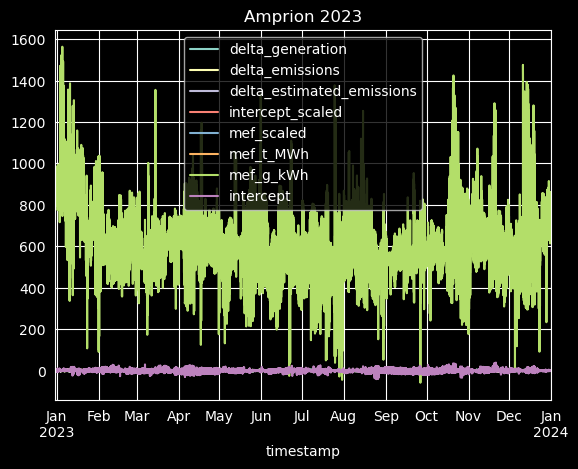

In [73]:
amprion_2023 = pd.read_csv('../results/run_2/amprion_2023/mef_final.csv', index_col=0)
amprion_2023.index = pd.to_datetime(amprion_2023.index, format='ISO8601')
amprion_2023.plot(title='Amprion 2023')

<Axes: title={'center': 'Amprion 2023'}, xlabel='timestamp'>

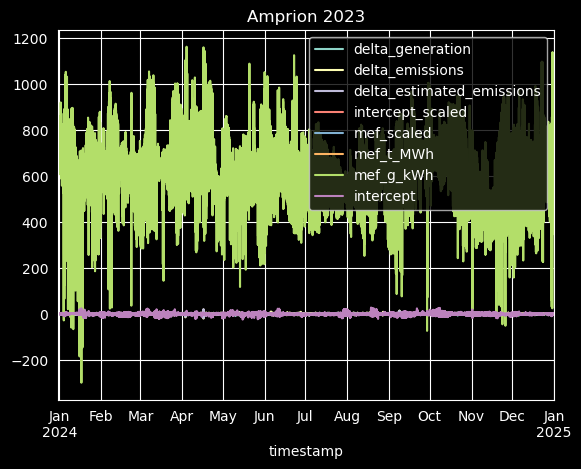

In [74]:
amprion_2024 = pd.read_csv('../results/run_2/amprion_2024/mef_final.csv', index_col=0)
amprion_2024.index = pd.to_datetime(amprion_2024.index, format='ISO8601')
amprion_2024.plot(title='Amprion 2023')

In [4]:
analyzer = MSDRAnalyzer(data=None, tso='amprion', year=None, run=None)

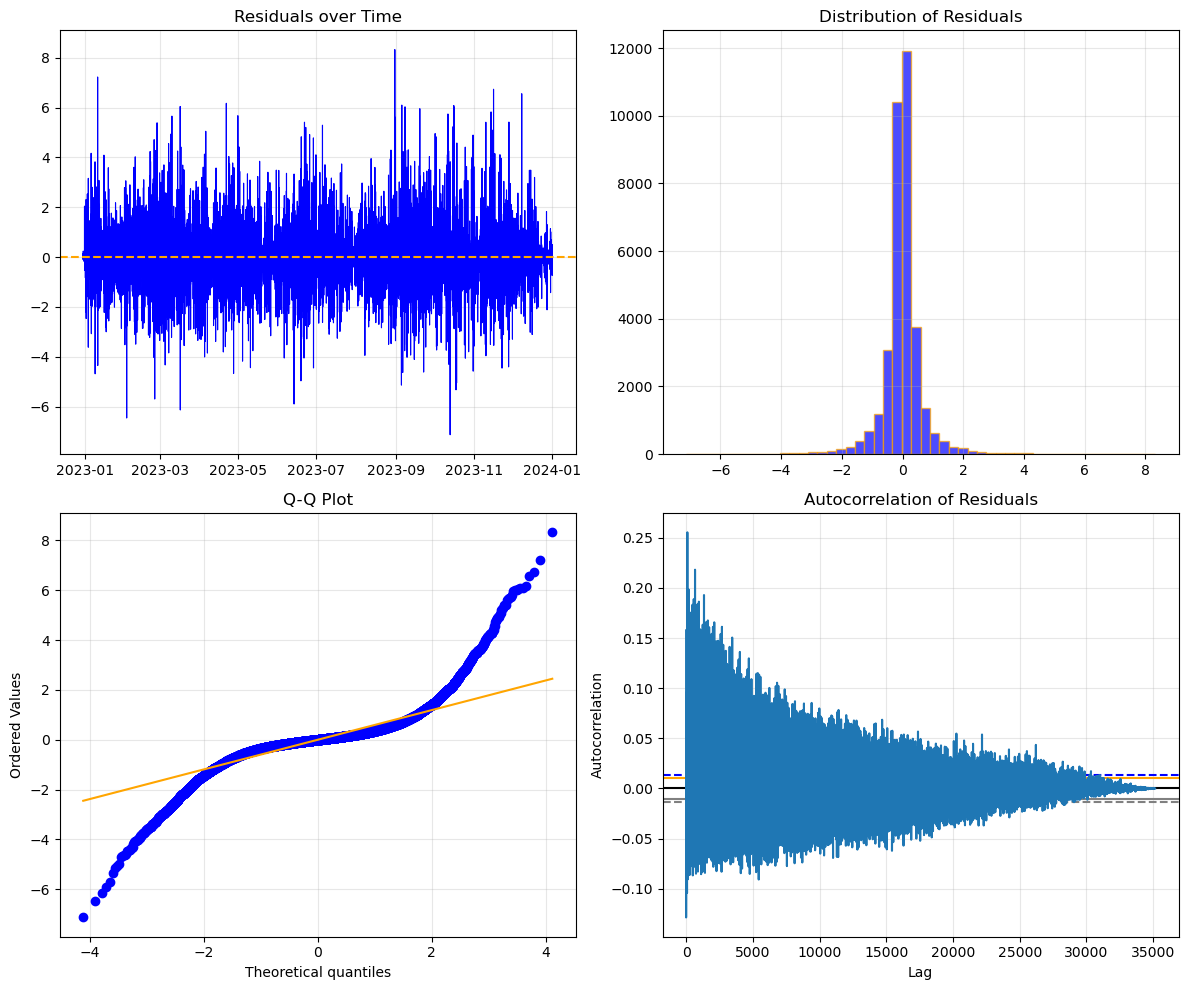

In [5]:
diagnose_model_fit(data=amprion_2023, orig_col='delta_emissions', esti_col='delta_estimated_emissions')

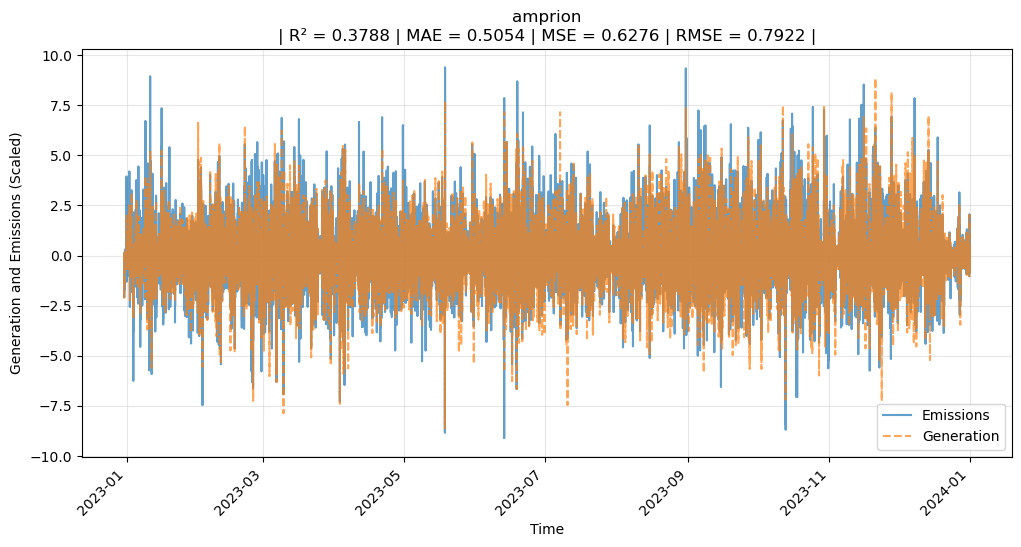

In [6]:
plot_over_time(data=amprion_2023, col1='delta_generation', col2='delta_emissions', col1_label='Generation', col2_label='Emissions', y_label='Generation and Emissions (Scaled)', out_filename='generation_emissions.png', plot=True)

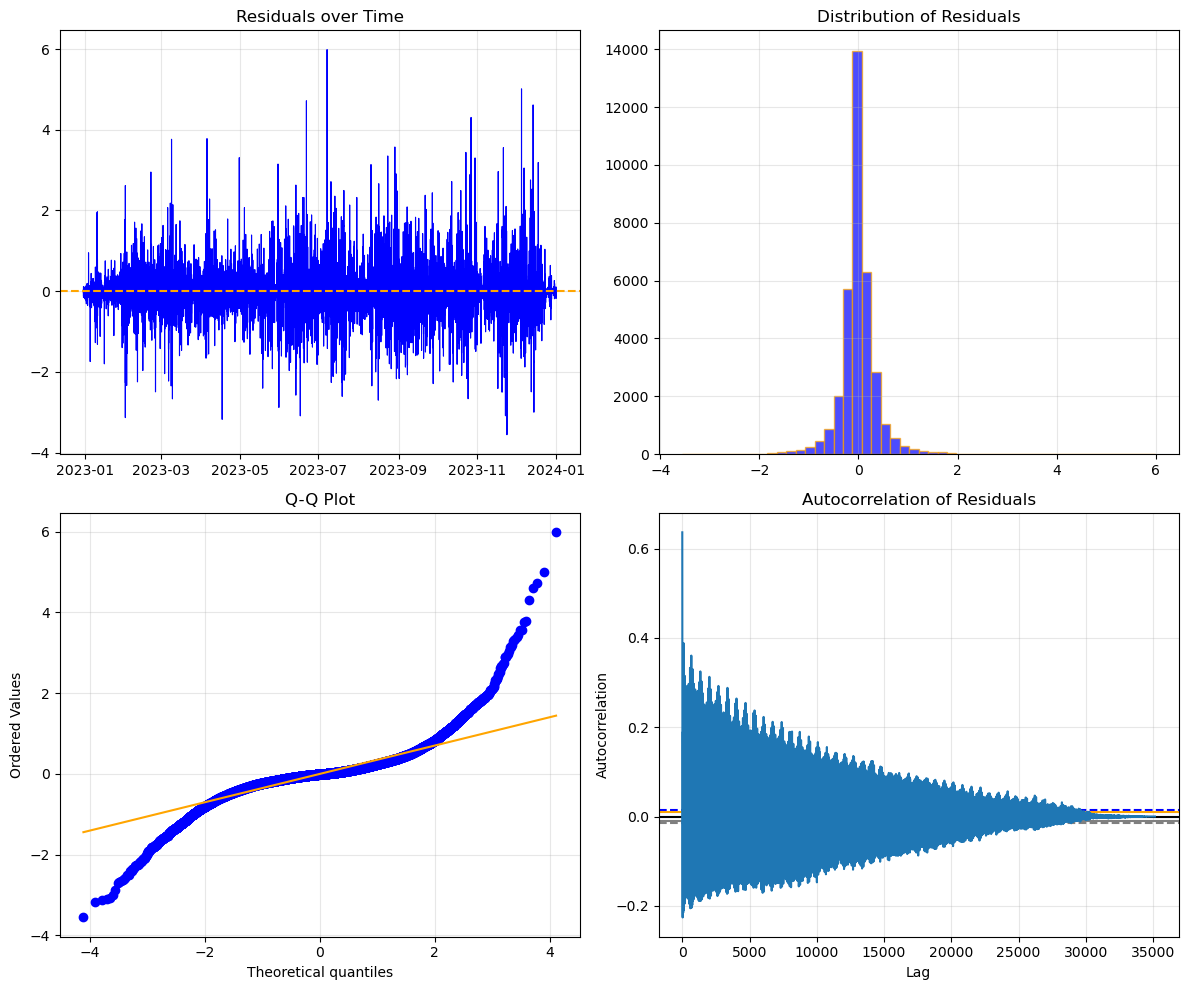

In [7]:
diagnose_model_fit(amprion_2023, 'delta_generation', 'delta_estimated_emissions')

In [75]:
import pandas as pd
import statsmodels.api as sm
data = pd.read_csv('../data/processed/final_tennet_2023_15min_utc_202212232315_202401010000.csv', index_col=0)
data.index = pd.to_datetime(data.index, format='ISO8601')

In [37]:
msdr = sm.tsa.MarkovRegression(
    endog=data['total_emissions'],
    exog=data['total_generation'],
    k_regimes=2,
    trend='c',
    order=1,
    switching_variance=True
)
msdr_res = msdr.fit()


In [38]:
summary_text = msdr_res.summary().as_text()
print(summary_text)

                        Markov Switching Model Results                        
Dep. Variable:        total_emissions   No. Observations:                35812
Model:               MarkovRegression   Log Likelihood             -188442.359
Date:                Mon, 02 Mar 2026   AIC                         376900.718
Time:                        12:41:28   BIC                         376968.606
Sample:                    12-23-2022   HQIC                        376922.319
                         - 01-01-2024                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         66.7945      0.479    139.382      0.000      65.855      67.734
x1             0.7059      0.001    767.897      0.0

In [44]:
msdr.k_regimes

2

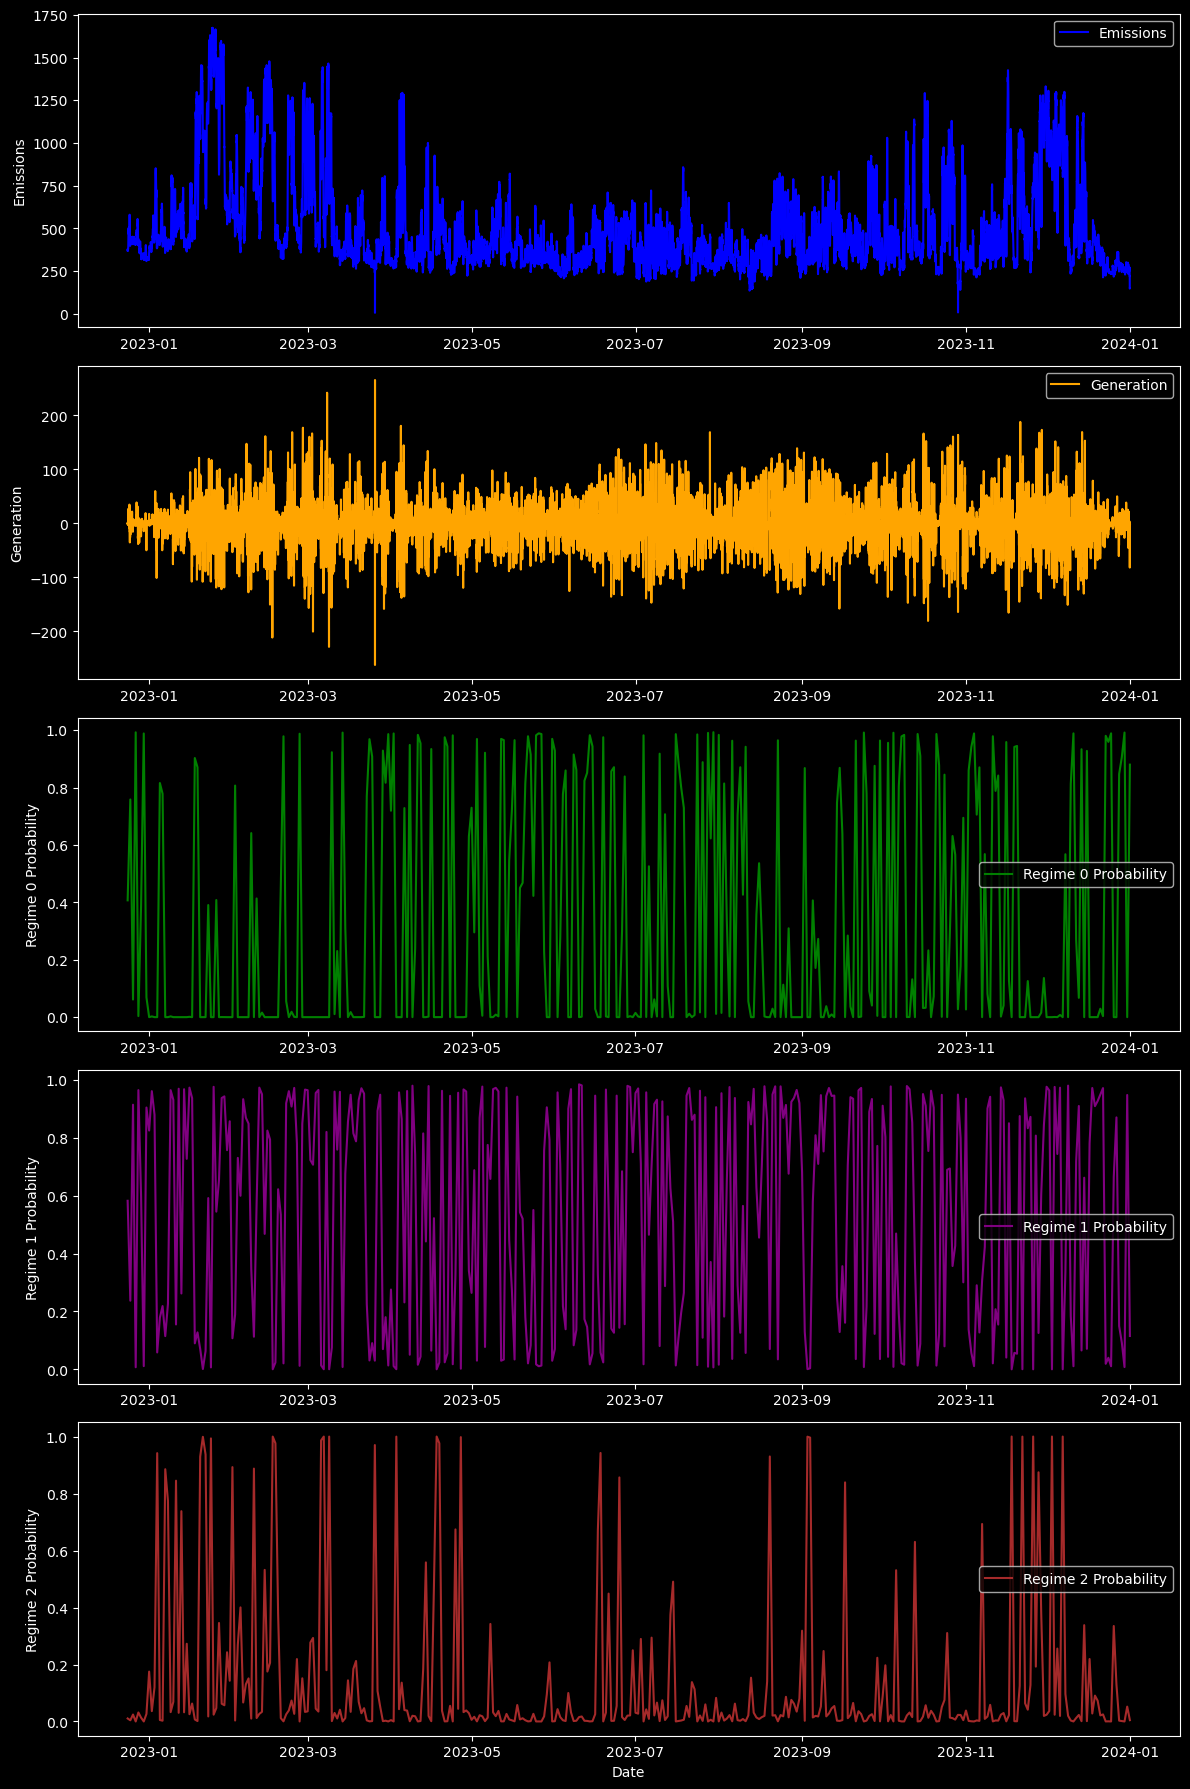

In [30]:
from matplotlib import pyplot as plt

# Resample the probabilities to daily frequency
daily_probs = msdr_res.smoothed_marginal_probabilities.resample('D').ffill()

# Plot the Emissions, Generation, and probabilities in separate plots
figure, axes = plt.subplots(5, 1, figsize=(12, 18))

# Plot Emissions data
axes[0].plot(data.index, data['total_emissions'], label='Emissions', color='blue')
axes[0].set_ylabel('Emissions')
axes[0].legend()

# Plot Generation data
axes[1].plot(data.index, data['delta_generation'], label='Generation', color='orange')
axes[1].set_ylabel('Generation')
axes[1].legend()

# Plot Smoothed probability of regime 0
axes[2].plot(daily_probs.index, daily_probs[0], label='Regime 0 Probability', color='green')
axes[2].set_ylabel('Regime 0 Probability')
axes[2].legend()

# Plot Smoothed probability of regime 1
axes[3].plot(daily_probs.index, daily_probs[1], label='Regime 1 Probability', color='purple')
axes[3].set_ylabel('Regime 1 Probability')
axes[3].legend()

# Plot Smoothed probability of regime 2
axes[4].plot(daily_probs.index, daily_probs[2], label='Regime 2 Probability', color='brown')
axes[4].set_ylabel('Regime 2 Probability')
axes[4].legend()

plt.xlabel('Date')
plt.tight_layout()
plt.show()

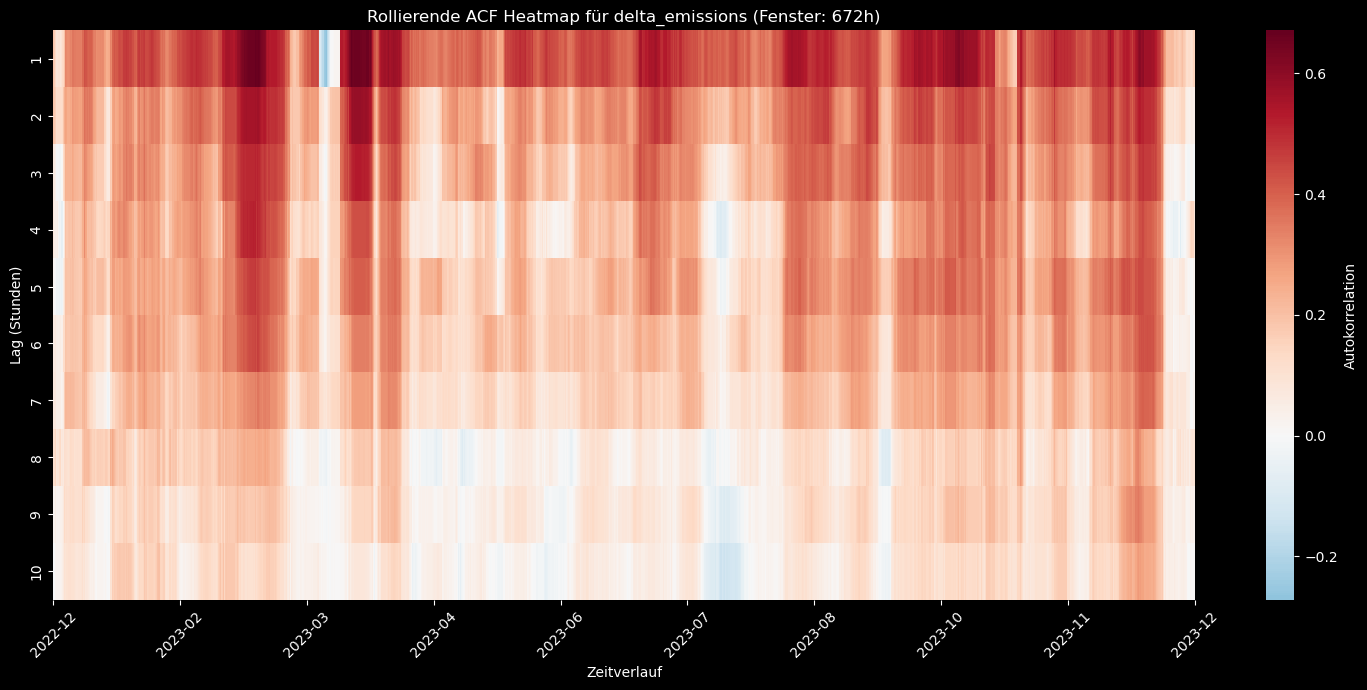

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import acf

def plot_rolling_acf_datetime(data, column, window_size=672, max_lag=10, step=500):
    series = data[column]
    acf_matrix = []
    time_labels = []

    # Rollierende Berechnung
    for i in range(0, len(series) - window_size, step):
        window = series.iloc[i : i + window_size].dropna()
        if len(window) < window_size: continue

        acf_values = acf(window, nlags=max_lag)
        acf_matrix.append(acf_values[1:])
        # Wir nehmen den Zeitstempel der MITTE des Fensters für die Beschriftung
        time_labels.append(series.index[i + window_size // 2])

    acf_df = pd.DataFrame(acf_matrix, index=time_labels, columns=range(1, max_lag+1))

    plt.figure(figsize=(15, 7))
    # Heatmap zeichnen
    ax = sns.heatmap(acf_df.T, cmap='RdBu_r', center=0, cbar_kws={'label': 'Autokorrelation'})

    # X-Achsen Beschriftung fixen (Datetime Handling für Heatmaps ist trickreich)
    # Wir setzen nur alle N Ticks eine Beschriftung, um Überlappung zu vermeiden
    n_ticks = 10
    tick_indices = np.linspace(0, len(time_labels) - 1, n_ticks, dtype=int)
    ax.set_xticks(tick_indices)
    ax.set_xticklabels([time_labels[i].strftime('%Y-%m') for i in tick_indices], rotation=45)

    plt.title(f'Rollierende ACF Heatmap für {column} (Fenster: {window_size}h)')
    plt.ylabel('Lag (Stunden)')
    plt.xlabel('Zeitverlauf')
    plt.tight_layout()
    plt.show()

# Aufruf (angenommen dein Index ist bereits ein DatetimeIndex)
plot_rolling_acf_datetime(data, 'delta_emissions', step=1)

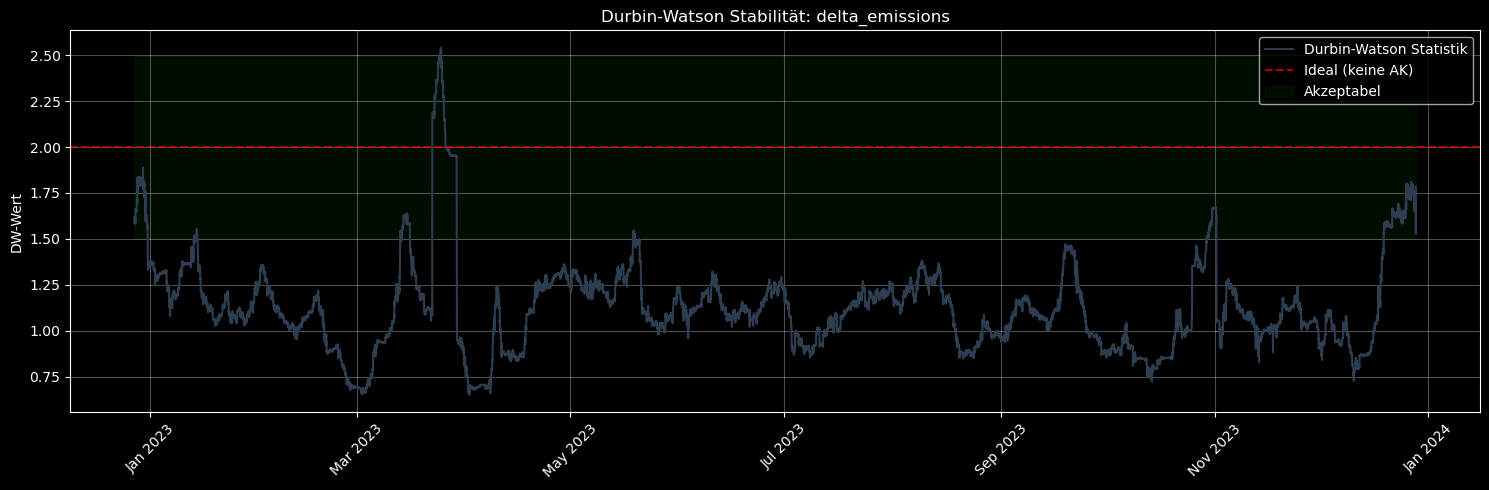

In [66]:
from statsmodels.stats.stattools import durbin_watson

def plot_rolling_dw_datetime(data, column, window_size=672, step=500):
    series = data[column]
    dw_values = []
    time_indices = []

    for i in range(0, len(series) - window_size, step):
        window = series.iloc[i:i+window_size].dropna()
        dw_values.append(durbin_watson(window))
        time_indices.append(series.index[i + window_size // 2])

    fig, ax = plt.subplots(figsize=(15, 5))
    ax.plot(time_indices, dw_values, label='Durbin-Watson Statistik', color='#2c3e50', lw=1.5)

    # Referenzlinien
    ax.axhline(2, color='red', linestyle='--', alpha=0.7, label='Ideal (keine AK)')
    ax.fill_between(time_indices, 1.5, 2.5, color='green', alpha=0.1, label='Akzeptabel')

    # Zeitachsen-Formatierung
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=45)

    ax.set_title(f'Durbin-Watson Stabilität: {column}')
    ax.set_ylabel('DW-Wert')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_rolling_dw_datetime(data, 'delta_emissions', step=1)

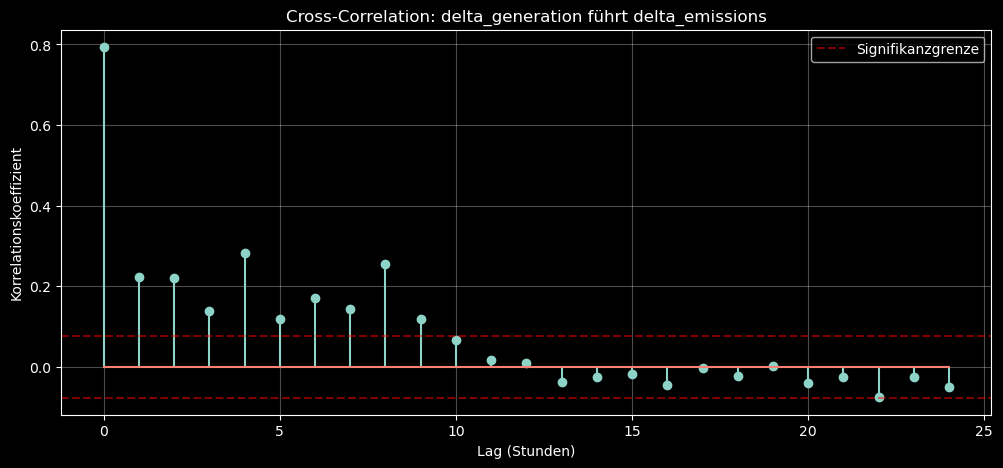

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import ccf

def plot_cross_correlation(data, x_col, y_col, lags=24):
    # Cross-Correlation berechnen
    # ccf(x, y) misst, wie x die zukünftigen Werte von y vorhersagt
    cross_corr = ccf(data[x_col].dropna(), data[y_col].dropna(), adjusted=False)[:lags+1]

    plt.figure(figsize=(12, 5))
    lags_range = range(len(cross_corr))

    # Plotting
    plt.stem(lags_range, cross_corr)

    # Signifikanzgrenze (ca. 2/sqrt(n))
    limit = 2 / np.sqrt(len(data[x_col].dropna()))
    plt.axhline(limit, color='red', linestyle='--', alpha=0.5, label='Signifikanzgrenze')
    plt.axhline(-limit, color='red', linestyle='--', alpha=0.5)

    plt.title(f'Cross-Correlation: {x_col} führt {y_col}')
    plt.xlabel('Lag (Stunden)')
    plt.ylabel('Korrelationskoeffizient')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# Anwendung: Ersetze 'deine_exogene_variable' durch deinen Spaltennamen
plot_cross_correlation(data.iloc[:672], 'delta_generation', 'delta_emissions')

Starte rollierende Analyse über 35812 Datenpunkte...


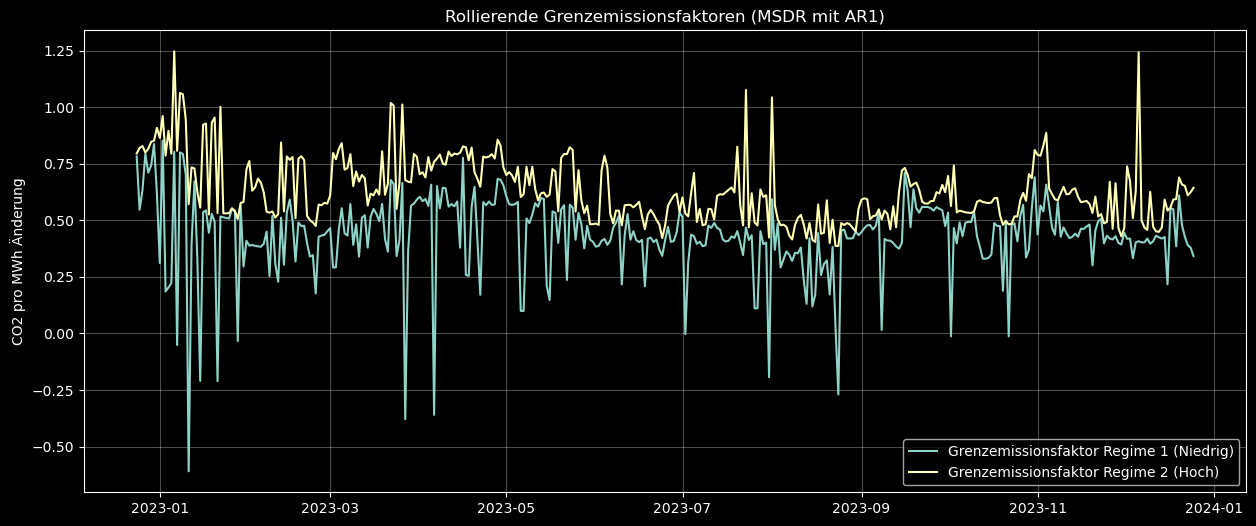

In [71]:
import pandas as pd
import numpy as np
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
import matplotlib.pyplot as plt

# Parameter definieren
window_size = 672
step_size = 96  # Beispiel: Fenster rutscht jede Woche um 168h weiter (schneller als step=1)
results = []

# Vorbereitung der Daten (Stelle sicher, dass keine NaNs vorhanden sind)
df_clean = data[['delta_emissions', 'delta_generation']].dropna()

print(f"Starte rollierende Analyse über {len(df_clean)} Datenpunkte...")

# Rollierender Loop
for i in range(0, len(df_clean) - window_size, step_size):
    # Fenster ausschneiden
    window = df_clean.iloc[i : i + window_size]

    try:
        # MSDR Modell definieren
        # k_regimes=2: "Sauber" vs. "Dreckig"
        # order=1: Berücksichtigt die Autokorrelation (dein Ljung-Box Ergebnis)
        # exog: Deine Erzeugungsdaten (Grenzemissionsfaktor)
        model = MarkovRegression(
            window['delta_emissions'],
            k_regimes=3,
            exog=window['delta_generation'],
            order=1,
            switching_variance=True,
            switching_trend=True,
            switching_exog=True
        )

        # Modell fitten (search_reps hilft gegen lokale Maxima)
        res = model.fit(search_reps=10, disp=False)

        # Ergebnisse extrahieren
        # 'x1' ist üblicherweise der Name des exogenen Regressors in der Summary
        beta_low = res.params['x1[0]']
        beta_high = res.params['x1[1]']

        # Sicherstellen, dass beta_low immer der kleinere Wert ist (Sortierung der Regimes)
        betas = sorted([beta_low, beta_high])

        results.append({
            'start_date': window.index[0],
            'end_date': window.index[-1],
            'gef_regime_1': betas[0],
            'gef_regime_2': betas[1],
            'aic': res.aic
        })

    except Exception as e:
        print(f"Fehler im Fenster ab {window.index[0]}: {e}")
        continue

# Ergebnisse in DataFrame umwandeln
df_results = pd.DataFrame(results)

# Visualisierung der Grenzemissionsfaktoren über die Zeit
plt.figure(figsize=(15, 6))
plt.plot(df_results['start_date'], df_results['gef_regime_1'], label='Grenzemissionsfaktor Regime 1 (Niedrig)')
plt.plot(df_results['start_date'], df_results['gef_regime_2'], label='Grenzemissionsfaktor Regime 2 (Hoch)')
plt.title('Rollierende Grenzemissionsfaktoren (MSDR mit AR1)')
plt.ylabel('CO2 pro MWh Änderung')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()